In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from uncertainties import ufloat
from uncertainties import unumpy as unp

(3, 52554)


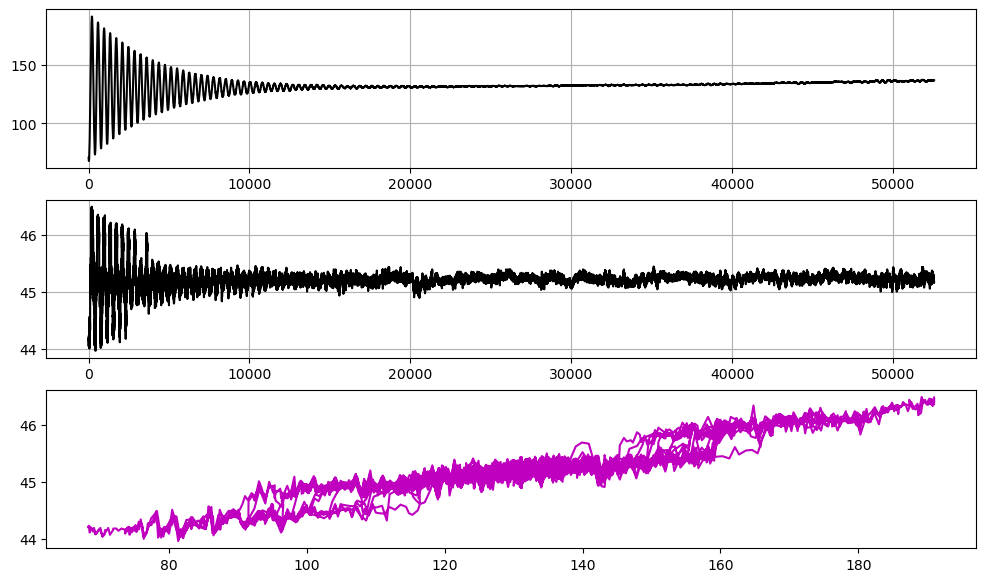

In [5]:
#night meas analysis
night = np.loadtxt('m5/m5_p0_nacht.txt', skiprows=2, unpack=True)
print(night.shape)
plt.figure(figsize=(12,7))
plt.subplot(311)
plt.plot(night[0,:],night[1,:], 'k')
plt.grid()
plt.subplot(312)
plt.plot(night[0,:],night[2,:], 'k')
plt.grid()
plt.subplot(313)
plt.plot(night[1,:],night[2,:], 'm')

In [6]:
def theta(t, A, tau, w, phase, h):
        return A * np.exp(-t/tau) * np.sin(w*t + phase) + h

def lin(x,a,b):
        return a*x + b

def rotate_data(t, xdata, ydata):
    popt, pcov = curve_fit(lin, xdata=xdata, ydata=ydata)
    phi = np.arctan(popt[0])
    
    x = xdata * np.cos(-phi) - (ydata - popt[1]) * np.sin(-phi)
    y = xdata * np.sin(-phi) + (ydata - popt[1]) * np.cos(-phi)

    return x, y

def fit(t, xdata, ydata, p0: list = [180, 2000, 0.017, -1.5, 630], cutoff: int = 0):
    x, y = rotate_data(t, xdata, ydata)

    popt, pcov = curve_fit(theta, t[cutoff:], x[cutoff:], p0=p0)

    fig, (ax1, ax2) = plt.subplots(2, sharex=True)

    ax1.plot(t, x - popt[4], 'k.', ms=1)
    ax1.plot(t[cutoff:], theta(t[cutoff:], *popt) - popt[4], 'r')
    #ax1.set_xlabel('t')
    ax1.set_ylabel('x')

    ax2.errorbar(t, y, fmt='k.', capsize=1, linewidth=0.6, ms=0.8)
    ax2.set_xlabel('t')
    ax2.set_ylabel('y')

    #T = 2 * np.pi / ufloat(popt[2], pcov[2,2]**0.5)

    return unp.uarray(popt, np.sqrt(np.diag(pcov)))

In [7]:
def conversion(h1,h2):
    # known length of h, v in m
    l_h = unp.uarray(46.1, 0.1) #cm
    l_v = unp.uarray(32.8, 0.1) #cm
    
    #conversion factor calc + uncertainty

    #calculation
    #h_diff = h2-h1
    #v_diff = v2-v1
    # pixel conversion factors
    #x_px = l_h * unp.cos(unp.arctan(h_diff[0]/h_diff[1])) # m / fake m
    #y_px = l_v * unp.cos(unp.arctan(v_diff[1]/v_diff[0])) # m / fake m
    #print(h_diff)
    #print(h_diff[1])
    #print(h_diff[0])

    #print(conversion(h1,h2,v1,v2))
    l_h = unp.uarray(46.1, 0.1) #cm
    l_v = unp.uarray(32.8, 0.1) #cm
    
    alpha = unp.arctan( (h2[1]-h1[1])/(h2[0]-h1[0]) )
    H = (h2[1]-h1[1])/unp.sin(alpha)
    
    return l_h/H

In [8]:
# input data: virtual meters for h and v
# h
# NEW FOR EACH RUN:
h1 = unp.uarray([-199.5 ,-72.7 ], [5,5]) # coordinates in virt m 
h2 = unp.uarray([ 88.6, -74.69], [5,5])# virt m
# v 
#v1 = unp.uarray([22.02,-794.6], [10,10]) # virt m
#v2 = unp.uarray([-16.84,-126.1], [10,10]) # virt m

print(conversion(h1,h2))

0.160+/-0.004


In [51]:
# calculate G , incl uncertainties
def G_12(R, theta1, theta2, T, conversion_factor):
    #technical drawing
    m = unp.uarray(0.028, 0)  #0.028 #kg tech drawing

    #I = m*l**2/2 #kg m^2, using MIT estimated formula
    l=unp.uarray(0.12, 0.001)-unp.uarray(0.0171, 0.001)
    #l=unp.uarray(0.12, 0.001)
    rk = unp.uarray(0.0171,0.00001)# radius of pendulum spheres
    #I = 2*m *( 2/5 * rk**2 + (l/2)**2)  #improvement of I
    I = m*l**2/2 #kg m^2, using MIT estimated formula
    
    # laser meas
    L =  unp.uarray(4.321, 0.001) #m
        
    #measured:
    M = unp.uarray(1.5,0.01)  #kg +/-10g
    
    #delta_r = 0.0
    #ADJUST r1, r2, r3
    #r = unp.uarray( R  + delta_r, 0.003) #m  51.722+/-0.011 #meas with messschieber in the air, could be improved

        
    #fit: T0, dtheta1, dtheta2
    h1=theta1*conversion_factor #conversion factor for vid setup 1 in cm/'m'. used squared addition here
    h2=theta2*conversion_factor
    
    #dtheta= unp.arctan( (theta2 - theta1)*0.01 / 4.321) #0.01 go from cm to m
    dtheta= unp.arctan( ((h2 - h1)*0.5)*0.01 / 4.321) #0.01 go from cm to m
        
    #units kg m^2 /s^2  * m^2/kg^2/m
    G = (r)**2 * (l)/(8*M) * (2*np.pi/T)**2 * dtheta  #using MIT I that cancels, we could get a correction here

    #print('eq1:',h1,'eq2:',h2, 'in cm')
    
    return G

period from zero measurement =  377.328+/-0.016


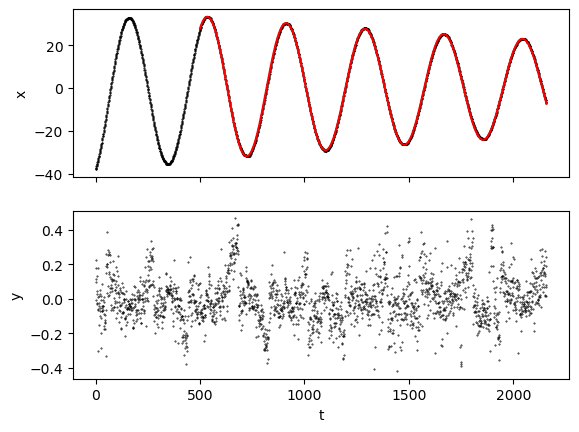

In [10]:
#get period T0
T =  2*np.pi/fit(*np.loadtxt('m7/m7_p0.txt', skiprows=2, unpack=True), cutoff=500)[2]
print('period from zero measurement = ', T)

G12 = (7.1+/-0.7)e-11
G01 = (5.9+/-0.5)e-11
G02 = (8.3+/-0.8)e-11


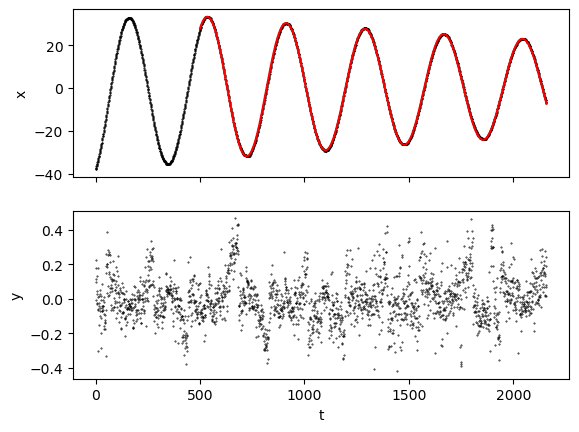

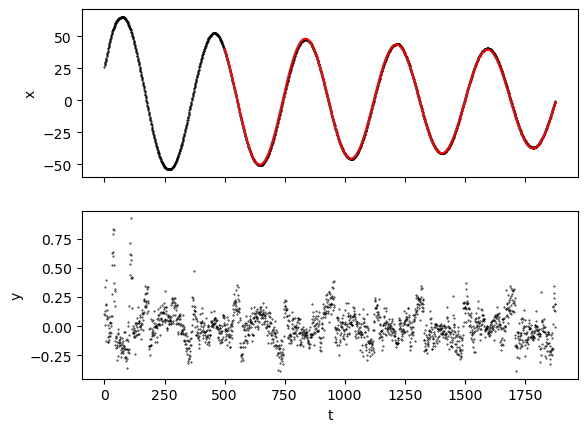

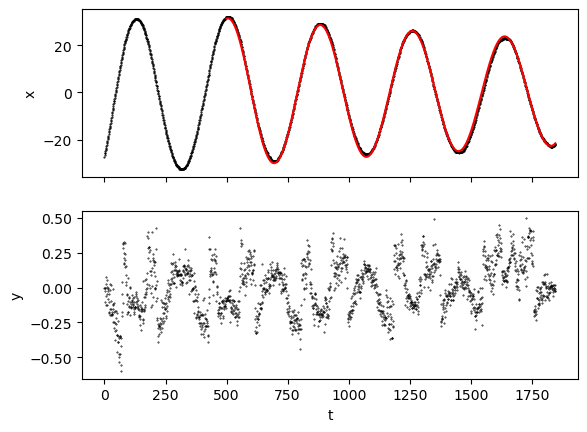

In [67]:
#T = ufloat(379.9587037978669, 0) # mean of both, in principle we have zero measurement for full glory
#fit: T0, dtheta1, dtheta2
#theta1=unp.uarray(1042.074833852749, 0 ) #conversion factor for vid setup 1 in cm/'m'. used squared addition here
#theta2=unp.uarray(1249.6597283089984, 0)
theta0 = fit(*np.loadtxt('m7/m7_p0.txt', skiprows=2, unpack=True), cutoff=500)[4]
theta1 = fit(*np.loadtxt('m7/m7_p1_r2.txt', skiprows=2, unpack=True), cutoff=500)[4]
theta2 = fit(*np.loadtxt('m7/m7_p2_r2.txt', skiprows=2, unpack=True), cutoff=500)[4]

#REMEMBER TO ADJUST R:
R1 = 0.087
R2 = 0.068
R3 = 0.053

delta_r = 0.0
r = unp.uarray( R2  + delta_r, 0.003) 

conversion_factor =conversion(h1,h2)
print('G12 =',G_12(r, theta1, theta2, T, conversion_factor)) # *2 for G01,2 
print('G01 =',G_12(r, theta1, theta0, T, conversion_factor)*2)
print('G02 =',G_12(r, theta0, theta2, T, conversion_factor)*2)

In [184]:
#weighted mean: 


x = np.array((6.8e-11,6.4e-11,6.6e-11))
m = np.mean(x)

err = np.array((1.1e-11,1.1e-11,1.1e-11))
w = 1/err**2 #weights

#diff errors weighted mean
err = np.sqrt(1/(np.sum(w)))
WM = np.sum(x*w)/np.sum(w)

#error on this mean
print('normal mean',m)
print('weighted mean',WM)
print('err=',np.sum(err)/np.sqrt(3))

normal mean 6.6e-11
weighted mean 6.6e-11
err= 3.666666666666667e-12


In [185]:
#all weighted means:
m5 =  6.6e-11
m5_err = 0.4e-11

m5_vac = 9.6e-11
m5_vac_err = 0.5e-11

m6 =  11.0e-11
m6_err = 0.2e-11

m5_r1 = 8.0e-11
m5_r1_err = 0.2e-11

m5_r2 = 6.7e-11
m5_r2_err = 0.2e-11

m5_r3 = 7.2e-11
m5_r3_err = 0.3e-11
print('important argument: 01,02 scatter due to systematic so if we average we kill the systematic! think about if uncert are affected by this syst')

important argument: 01,02 scatter due to systematic so if we average we kill the systematic! think about if uncert are affected by this syst


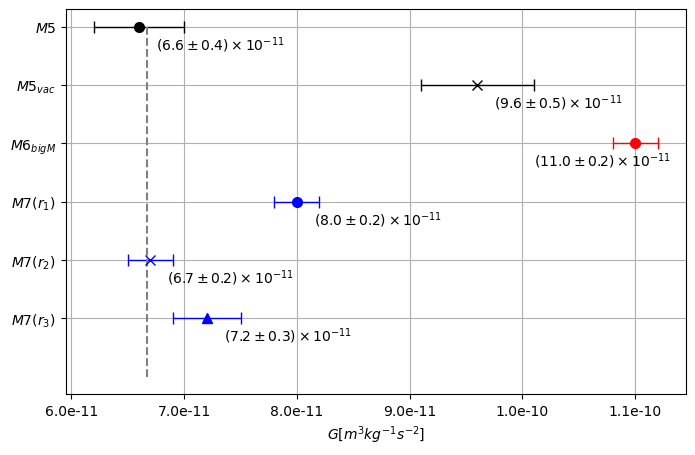

In [189]:
# plot for all results, incl errorbars
plt.figure(figsize=(8,5))
y_pos = [6,5,4,3,2,1]

plt.errorbar(m5, 6, xerr=m5_err, fmt='ko', capsize=4, elinewidth=1, markersize=7, linestyle='none', label='m5')

plt.errorbar(m5_vac, 5, xerr=m5_vac_err, fmt='kx', capsize=4, elinewidth=1, markersize=7, linestyle='none', label='m5_vac')

plt.errorbar(m6, 4, xerr=m6_err, fmt='ro', capsize=4, elinewidth=1, markersize=7, linestyle='none', label='m6')

#varying r
plt.errorbar(m5_r1, 3, xerr=m5_r1_err, fmt='bo', capsize=4, elinewidth=1, markersize=7, linestyle='none', label='m5 r1')
plt.errorbar(m5_r2, 2, xerr=m5_r2_err, fmt='bx', capsize=4, elinewidth=1, markersize=7, linestyle='none', label='m5 r2')
plt.errorbar(m5_r3, 1, xerr=m5_r3_err, fmt='b^', capsize=4, elinewidth=1, markersize=7, linestyle='none', label='m5 r3')

plt.vlines(6.67e-11,0,6, 'gray', label='literature', linestyle='dashed')
plt.xlabel('$G [m^3 kg^{-1} s^{-2}]$')
plt.yticks([])
from matplotlib.ticker import FormatStrFormatter
plt.gca().xaxis.set_major_formatter(FormatStrFormatter('%.1e'))
#plt.legend()

# Set y-axis labels instead of numbers
plt.yticks(y_pos, ['$M5$','$M5_{vac}$','$M6_{bigM}$','$M7(r_1)$','$M7(r_2)$','$M7(r_3)$'])

plt.grid()

# ---- ADD VALUE LABELS ----
offset = 0.15e-11  # horizontal shift for text
off_down = 0.3
plt.text(m5 + offset, 6-off_down, r'$(6.6\pm0.4)\times10^{-11}$', va='center')
plt.text(m5_vac + offset, 5-off_down, r'$(9.6\pm0.5)\times10^{-11}$', va='center')
plt.text(m6 - 6*offset, 4-off_down, r'$(11.0\pm0.2)\times10^{-11}$', va='center')

plt.text(m5_r1 + offset, 3-off_down, r'$(8.0\pm0.2)\times10^{-11}$', va='center')
plt.text(m5_r2 + offset, 2-off_down, r'$(6.7\pm0.2)\times10^{-11}$', va='center')
plt.text(m5_r3 + offset, 1-off_down, r'$(7.2\pm0.3)\times10^{-11}$', va='center')

plt.savefig('results.png')